# ACF & PACF Analysis — Nifty 50 Daily Returns

## What this project covers
Autocorrelation and Partial Autocorrelation analysis on 
real Nifty 50 data (2019-2023).

## Key concepts
- ACF measures total correlation (direct + indirect effects)
- PACF measures only direct correlation at each lag
- Confidence band = ±1.96/√n = ±0.056

## Key findings
- Most lags show zero autocorrelation — market is largely efficient
- Significant pattern at lags 5, 6, 7 — weekly cycle (5 trading days)
- ACF shows more significant lags than PACF — indirect effects inflating ACF
- PACF reveals true direct effects: mainly lags 5, 6, 7

## Model suggestion
AR(7) model with φ₅, φ₆, φ₇ as meaningful coefficients

## Real world insight
Near-zero autocorrelation confirms Efficient Market Hypothesis.
Past returns barely predict future returns on Nifty 50.

## Libraries used
- yfinance — real market data
- statsmodels — ACF, PACF calculations
- matplotlib, numpy, pandas — analysis and visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Download Nifty 50 data — same as last time
nifty = yf.download("^NSEI", start="2019-01-01", end="2024-01-01")
prices = nifty['Close']

# Convert to returns — we always model returns not prices
returns = prices.pct_change().dropna()

print(f"Total days: {len(returns)}")
print(f"Mean return: {float(returns.mean()):.6f}")
print(f"Std deviation: {float(returns.std()):.6f}")

[*********************100%***********************]  1 of 1 completed

Total days: 1231
Mean return: 0.000642
Std deviation: 0.012040



/var/folders/77/ljf0pc6d5l14ft71759h4qrw0000gn/T/ipykernel_1576/3169341362.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Mean return: {float(returns.mean()):.6f}")
/var/folders/77/ljf0pc6d5l14ft71759h4qrw0000gn/T/ipykernel_1576/3169341362.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Std deviation: {float(returns.std()):.6f}")


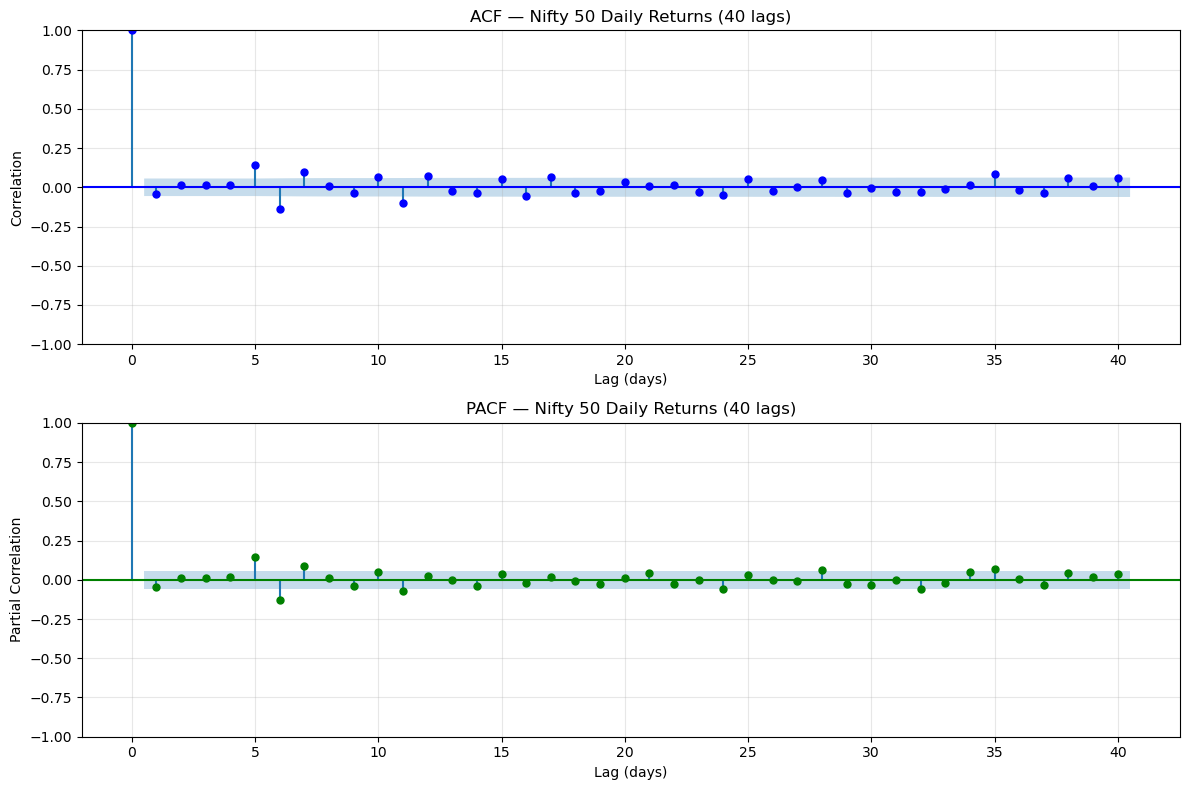

In [2]:
# Plot ACF — autocorrelation at each lag
# This shows TOTAL effect (direct + indirect) of past returns on today

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot
plot_acf(returns, lags=40, ax=axes[0], color='blue', 
         title='ACF — Nifty 50 Daily Returns (40 lags)')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Correlation')
axes[0].grid(True, alpha=0.3)

# PACF plot
plot_pacf(returns, lags=40, ax=axes[1], color='green',
          title='PACF — Nifty 50 Daily Returns (40 lags)')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial Correlation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Extract ACF and PACF values numerically
# confidence interval = 1.96/sqrt(n) — standard 95% threshold

n = len(returns)
confidence = 1.96 / np.sqrt(n)

acf_values = acf(returns, nlags=40, fft=True)
pacf_values = pacf(returns, nlags=40)

print(f"Confidence band: ±{confidence:.4f}")
print(f"\nSignificant ACF lags (outside ±{confidence:.4f}):")
for i, val in enumerate(acf_values[1:], 1):
    if abs(val) > confidence:
        print(f"  Lag {i}: ACF = {val:.4f}")

print(f"\nSignificant PACF lags (outside ±{confidence:.4f}):")
for i, val in enumerate(pacf_values[1:], 1):
    if abs(val) > confidence:
        print(f"  Lag {i}: PACF = {val:.4f}")

Confidence band: ±0.0559

Significant ACF lags (outside ±0.0559):
  Lag 5: ACF = 0.1418
  Lag 6: ACF = -0.1382
  Lag 7: ACF = 0.1000
  Lag 10: ACF = 0.0677
  Lag 11: ACF = -0.1017
  Lag 12: ACF = 0.0708
  Lag 16: ACF = -0.0583
  Lag 17: ACF = 0.0636
  Lag 35: ACF = 0.0849
  Lag 38: ACF = 0.0572
  Lag 40: ACF = 0.0582

Significant PACF lags (outside ±0.0559):
  Lag 5: PACF = 0.1437
  Lag 6: PACF = -0.1293
  Lag 7: PACF = 0.0893
  Lag 11: PACF = -0.0705
  Lag 24: PACF = -0.0588
  Lag 28: PACF = 0.0634
  Lag 32: PACF = -0.0579
  Lag 35: PACF = 0.0684


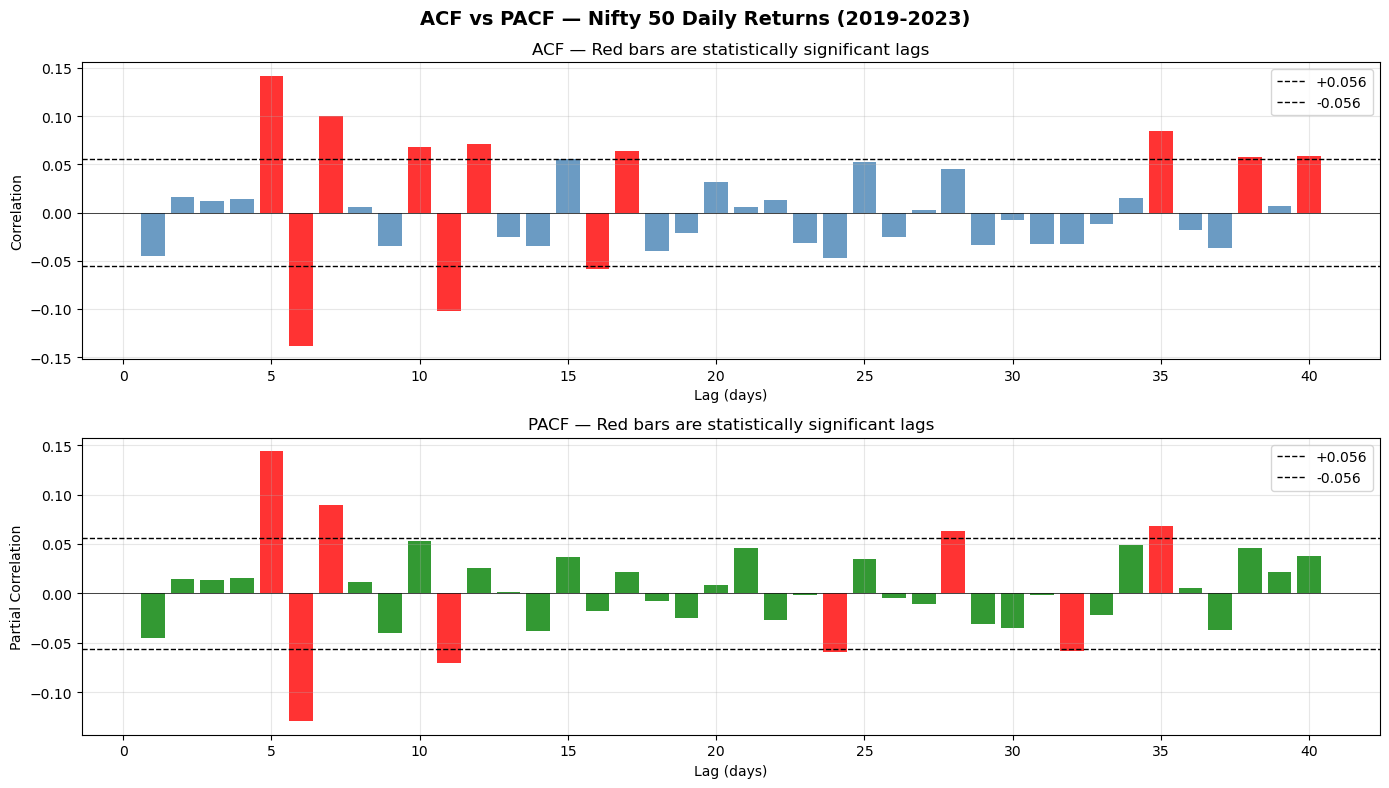

In [4]:
# Clean bar chart of significant vs insignificant lags
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

lags = np.arange(1, 41)
acf_vals = acf_values[1:]
pacf_vals = pacf_values[1:]

# ACF bar chart
colors_acf = ['red' if abs(v) > confidence else 'steelblue' for v in acf_vals]
axes[0].bar(lags, acf_vals, color=colors_acf, alpha=0.8)
axes[0].axhline(y=confidence, color='black', linestyle='--', linewidth=1, label=f'+{confidence:.3f}')
axes[0].axhline(y=-confidence, color='black', linestyle='--', linewidth=1, label=f'-{confidence:.3f}')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_title('ACF — Red bars are statistically significant lags')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Correlation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PACF bar chart
colors_pacf = ['red' if abs(v) > confidence else 'green' for v in pacf_vals]
axes[1].bar(lags, pacf_vals, color=colors_pacf, alpha=0.8)
axes[1].axhline(y=confidence, color='black', linestyle='--', linewidth=1, label=f'+{confidence:.3f}')
axes[1].axhline(y=-confidence, color='black', linestyle='--', linewidth=1, label=f'-{confidence:.3f}')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('PACF — Red bars are statistically significant lags')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ACF vs PACF — Nifty 50 Daily Returns (2019-2023)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()